In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
FP=pd.read_csv("/content/drive/MyDrive/ames_data/AmesHousing_clean.csv")

In [3]:
FP=pd.get_dummies(FP,columns=["Neighborhood","Sale Type"],prefix=["Neighborhood","SaleType"])

I converted the categorical features "Neighborhood" and "Sale Type" into numerical columns using one-hot encoding. This allows the model to use these features because machine learning methods require numerical input.

In [4]:
FP["OverallQual_ord"]=FP["Overall Qual"]

In [5]:
scaler=StandardScaler()
FP[["GrLivArea_std","LotArea_std"]]=scaler.fit_transform(FP[["Gr Liv Area","Lot Area"]])

I standardised "Gr Liv Area" and "Lot Area" to put them on the same scale. This helps prevent features with larger values from dominating the analysis.

In [6]:
FP["price_per_sqft"]=FP["SalePrice"]/FP["Gr Liv Area"].replace({0:np.nan})
FP["price_per_sqft"]=FP["price_per_sqft"].fillna(FP["price_per_sqft"].median())

price_per_sqft

This feature represents the house price relative to its living area.
It can help compare houses of different sizes more fairly.

In [7]:
FP["total_bathrooms"]=FP["Full Bath"]+0.5*FP["Half Bath"]

total_bathrooms combines full and half bathrooms into one value.
It helps represent the total bathroom capacity of the house.

In [8]:
FP["quality_x_area"]=FP["Overall Qual"]*FP["Gr Liv Area"]

quality_x_area combines house quality and living area.
It may better represent the value of large high-quality homes.

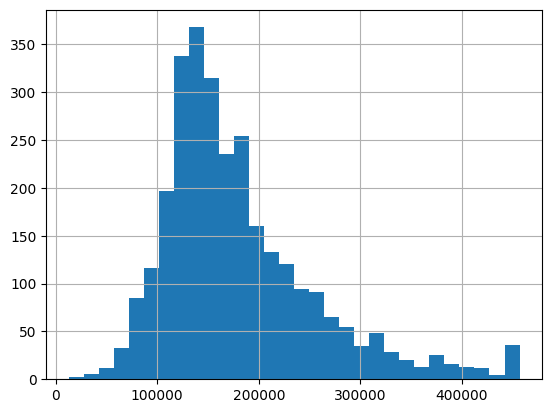

In [9]:
FP["SalePrice"].hist(bins=30)
plt.show()

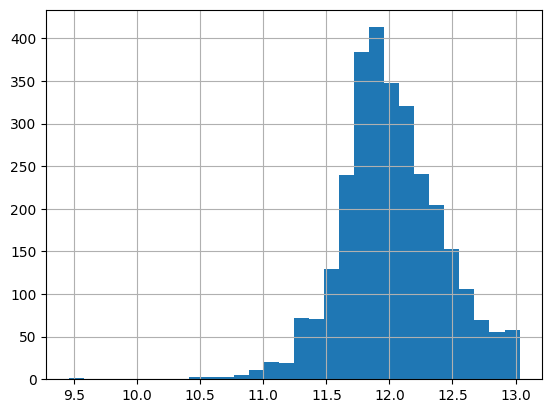

In [10]:
FP["SalePrice_log1p"]=np.log1p(FP["SalePrice"])
FP["SalePrice_log1p"].hist(bins=30)
plt.show()

SalePrice_log1p reduces skewness in the price distribution.
This can help models learn patterns more effectively.

In [11]:
FP["age_at_sale"]=FP["Yr Sold"]-FP["Year Built"]
FP["age_group"]=pd.cut(FP["age_at_sale"],bins=[-1,5,20,200],labels=["New","Recent","Old"],right=False)

age_group groups houses by age.
This may capture how house age influences property value.

In [12]:
corr_matrix=FP.select_dtypes(include=["number"]).corr()
print(corr_matrix)

                    Order       PID  MS SubClass  Lot Frontage  Lot Area  \
Order            1.000000  0.173593     0.011797     -0.006102  0.031354   
PID              0.173593  1.000000    -0.001281     -0.087894  0.034868   
MS SubClass      0.011797 -0.001281     1.000000     -0.391497 -0.204613   
Lot Frontage    -0.006102 -0.087894    -0.391497      1.000000  0.362758   
Lot Area         0.031354  0.034868    -0.204613      0.362758  1.000000   
Overall Qual    -0.048500 -0.263147     0.039419      0.198917  0.097188   
Overall Cond    -0.011054  0.104451    -0.067349     -0.067140 -0.034759   
Year Built      -0.052319 -0.343388     0.036579      0.114341  0.023258   
Year Remod/Add  -0.075566 -0.157111     0.043397      0.086139  0.021682   
Mas Vnr Area    -0.031045 -0.225672     0.003634      0.201685  0.125950   
BsmtFin SF 1    -0.032313 -0.098412    -0.060019      0.198161  0.191574   
BsmtFin SF 2    -0.002758 -0.001245    -0.070847      0.039157  0.083198   
Bsmt Unf SF 

In [13]:
FP=FP.drop(columns=["Garage Area"])

 Remove redundant features
After checking the correlation matrix, I noticed that `Garage Cars` and `Garage Area` are highly correlated.  
To avoid redundant information, I removed `Garage Area`.

In [14]:
FP_features=FP
FP_features.to_csv("/content/drive/MyDrive/ames_data/AmesHousing_features.csv",index=False)